# Dual Optical Flow Multi-Scale Motion Detection

This notebook implements a **dual optical flow** approach for multi-scale motion detection:

## Architecture

```
┌─────────────────────────────────────────────────────────────────┐
│  PIPELINE 1: Upscale (for small objects)                       │
│  ┌──────────┐    ┌──────────┐    ┌──────────┐    ┌──────────┐  │
│  │Frame@1.5x│───►│   OF1    │───►│    H1    │───►│Residual1 │  │
│  └──────────┘    │(upscale) │    │(upscale) │    │  @1.5x   │  │
│                  └──────────┘    └──────────┘    └────┬─────┘  │
│                                                       │        │
│                                              Detect @ 1.5x     │
└───────────────────────────────────────────────────────┼────────┘
                                                        │
┌───────────────────────────────────────────────────────┼────────┐
│  PIPELINE 2: Original + Downscale (medium/large)      │        │
│  ┌──────────┐    ┌──────────┐    ┌──────────┐    ┌────┴─────┐  │
│  │Frame@1.0x│───►│   OF2    │───►│    H2    │───►│Residual2 │  │
│  └──────────┘    │(default) │    │(default) │    │  @1.0x   │  │
│                  └──────────┘    └──────────┘    └────┬─────┘  │
│                                                       │        │
│                                         ┌─────────────┼────────┤
│                                         │             │        │
│                                  Detect @ 1.0x   Detect @ 0.5x │
└─────────────────────────────────────────┼─────────────┼────────┘
                                          │             │
                                          ▼             ▼
                                    ┌─────────────────────┐
                                    │   Merge (NMS)       │
                                    │  Scale detections   │
                                    │  to original coords │
                                    └─────────────────────┘
```

## Why Two Optical Flows?

1. **OF1 (Upscale)**: Computed on 1.5x upscaled images
   - More features detected on small objects
   - Better ego-motion estimation for scenes with small movers
   - Optimized parameters for fine details

2. **OF2 (Default)**: Computed on original resolution
   - Standard tracking for medium/large objects
   - Residual is downscaled for large object detection
   - More robust for typical scenes

## Scale Levels
- **1.5x**: Small object detection (via OF1)
- **1.0x**: Medium object detection (via OF2)
- **0.5x**: Large object detection (via OF2, downscaled residual)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
# Configuration
VIDEO_PATH = 'data/videos/heli_1.mp4'
OUTPUT_DIR = 'data/dual_of_motion_frames'
DEBUG_DIR = 'data/dual_of_debug_frames'

# Create output directories
for dir_path in [OUTPUT_DIR, DEBUG_DIR]:
    Path(dir_path).mkdir(parents=True, exist_ok=True)

# ==============================================
# DEBUG MODE
# ==============================================
DEBUG = True

# ==============================================
# SCALE CONFIGURATION
# ==============================================
UPSCALE_FACTOR = 1.5      # For small object detection
DOWNSCALE_FACTOR = 0.5    # For large object detection

# ==============================================
# OPTICAL FLOW 1: Upscale Pipeline (1.5x)
# Optimized for fine details and small objects
# ==============================================
feature_params_upscale = dict(
    maxCorners=500,       # More corners for denser tracking
    qualityLevel=0.005,   # Lower threshold to detect weaker corners
    minDistance=10,       # Closer features (scaled up, so relatively same)
    blockSize=5           # Smaller block for fine details
)

lk_params_upscale = dict(
    winSize=(15, 15),     # Smaller window for fine tracking
    maxLevel=4,           # More levels for upscaled image
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01)
)

# ==============================================
# OPTICAL FLOW 2: Default Pipeline (1.0x + 0.5x)
# Standard parameters for general tracking
# ==============================================
feature_params_default = dict(
    maxCorners=400,
    qualityLevel=0.01,
    minDistance=15,
    blockSize=7
)

lk_params_default = dict(
    winSize=(21, 21),     # Standard window
    maxLevel=3,           # Standard pyramid
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01)
)

# ==============================================
# RANSAC Parameters
# ==============================================
RANSAC_REPROJ_THRESHOLD = 3.0

# ==============================================
# Detection Parameters per Scale
# ==============================================
detection_params = {
    1.5: {  # Upscale
        'threshold_sigma': 2.7,    # More sensitive
        'kernel_size': 3,          # Small kernel for fine details
        'min_area': 150,           # ~100 * 1.5^2 (scaled)
        'max_area': 112500         # ~50000 * 1.5^2 (scaled)
    },
    1.0: {  # Original
        'threshold_sigma': 3.0,
        'kernel_size': 3,
        'min_area': 100,
        'max_area': 50000
    },
    0.5: {  # Downscale
        'threshold_sigma': 3.5,    # Less sensitive (more noise at low res)
        'kernel_size': 5,          # Larger kernel
        'min_area': 25,            # ~100 * 0.5^2 (scaled)
        'max_area': 12500          # ~50000 * 0.5^2 (scaled)
    }
}

# Valid mask parameters
BORDER_MARGIN = 20

# Sampling
FRAME_SAMPLE_INTERVAL = 2

In [3]:
# ============================================
# Core Functions
# ============================================

def detect_features(gray, feature_params):
    """Detect Shi-Tomasi features with given parameters."""
    pts = cv2.goodFeaturesToTrack(gray, **feature_params)
    return pts


def track_features(prev_gray, curr_gray, prev_pts, lk_params):
    """Track features using Lucas-Kanade optical flow."""
    if prev_pts is None or len(prev_pts) == 0:
        return None, None, None
    
    curr_pts, status, err = cv2.calcOpticalFlowPyrLK(
        prev_gray, curr_gray, prev_pts, None, **lk_params
    )
    
    if status is not None:
        good_old = prev_pts[status.ravel() == 1]
        good_new = curr_pts[status.ravel() == 1]
        return good_old, good_new, status
    
    return None, None, None


def estimate_homography(old_pts, new_pts):
    """Estimate homography using RANSAC."""
    if old_pts is None or len(old_pts) < 4:
        return None, None
    
    H, inlier_mask = cv2.findHomography(
        old_pts, new_pts, cv2.RANSAC, RANSAC_REPROJ_THRESHOLD
    )
    return H, inlier_mask


def warp_frame(frame, H):
    """Warp frame using homography."""
    h, w = frame.shape[:2]
    warped = cv2.warpPerspective(frame, H, (w, h))
    return warped


def create_valid_mask(warped_frame, border_margin=20):
    """Create mask of valid pixels after warping."""
    if len(warped_frame.shape) == 3:
        valid_mask = cv2.cvtColor(warped_frame, cv2.COLOR_BGR2GRAY) > 0
    else:
        valid_mask = warped_frame > 0
    
    valid_mask = valid_mask.astype(np.uint8) * 255
    
    # Erode to avoid edge artifacts
    erode_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    valid_mask = cv2.erode(valid_mask, erode_kernel)
    
    # Exclude borders
    if border_margin > 0:
        valid_mask[:border_margin, :] = 0
        valid_mask[-border_margin:, :] = 0
        valid_mask[:, :border_margin] = 0
        valid_mask[:, -border_margin:] = 0
    
    return valid_mask


def compute_residual(curr_gray, warped_prev_gray, valid_mask=None):
    """Compute residual after ego-motion compensation."""
    residual = cv2.absdiff(curr_gray, warped_prev_gray)
    
    if valid_mask is not None:
        residual = cv2.bitwise_and(residual, residual, mask=valid_mask)
    
    return residual


def scale_image(image, scale):
    """Scale image by given factor."""
    if scale == 1.0:
        return image
    
    new_size = (int(image.shape[1] * scale), int(image.shape[0] * scale))
    
    if scale > 1.0:
        # Upscale with cubic interpolation
        return cv2.resize(image, new_size, interpolation=cv2.INTER_CUBIC)
    else:
        # Downscale with area interpolation (better for shrinking)
        return cv2.resize(image, new_size, interpolation=cv2.INTER_AREA)

In [4]:
# ============================================
# Detection Functions
# ============================================

def adaptive_threshold_mad(residual, valid_mask=None, sigma_multiplier=3.0):
    """
    Adaptive thresholding using Median Absolute Deviation (MAD).
    """
    if valid_mask is not None:
        valid_pixels = residual[valid_mask > 0]
    else:
        valid_pixels = residual.ravel()
    
    if len(valid_pixels) == 0:
        return np.zeros_like(residual, dtype=np.uint8), 15.0
    
    median_val = np.median(valid_pixels)
    mad = np.median(np.abs(valid_pixels.astype(np.float32) - median_val))
    mad_std = mad * 1.4826
    
    threshold = median_val + sigma_multiplier * mad_std
    threshold = max(threshold, 15)
    
    _, motion_mask = cv2.threshold(
        residual, threshold, 255, cv2.THRESH_BINARY
    )
    
    if valid_mask is not None:
        motion_mask = cv2.bitwise_and(motion_mask, motion_mask, mask=valid_mask)
    
    return motion_mask.astype(np.uint8), threshold


def morphological_cleanup(mask, kernel_size=5):
    """Apply morphological operations."""
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return mask


def extract_detections(mask, min_area=100, max_area=50000):
    """Extract bounding boxes from mask."""
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
    
    detections = []
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        
        if min_area < area < max_area:
            x = stats[i, cv2.CC_STAT_LEFT]
            y = stats[i, cv2.CC_STAT_TOP]
            w = stats[i, cv2.CC_STAT_WIDTH]
            h = stats[i, cv2.CC_STAT_HEIGHT]
            centroid = tuple(map(int, centroids[i]))
            
            detections.append({
                'bbox': (x, y, w, h),
                'centroid': centroid,
                'area': area
            })
    
    return detections


def detect_at_scale(residual, valid_mask, scale):
    """
    Run detection pipeline at a specific scale.
    
    Args:
        residual: Residual image at the given scale
        valid_mask: Valid mask at the given scale
        scale: Scale factor (1.5, 1.0, or 0.5)
    
    Returns:
        detections: List of detections at this scale
        motion_mask: Binary motion mask
        threshold: Threshold value used
    """
    params = detection_params[scale]
    
    # Threshold
    motion_mask_raw, threshold = adaptive_threshold_mad(
        residual, valid_mask, params['threshold_sigma']
    )
    
    # Morphology
    motion_mask = morphological_cleanup(motion_mask_raw, params['kernel_size'])
    
    # Extract detections
    detections = extract_detections(
        motion_mask, params['min_area'], params['max_area']
    )
    
    return detections, motion_mask, threshold


def scale_detections_to_original(detections, scale):
    """
    Scale detection coordinates back to original image space.
    """
    if scale == 1.0:
        for det in detections:
            det['scale'] = scale
        return detections
    
    inv_scale = 1.0 / scale
    
    scaled_detections = []
    for det in detections:
        x, y, w, h = det['bbox']
        cx, cy = det['centroid']
        
        scaled_detections.append({
            'bbox': (
                int(x * inv_scale),
                int(y * inv_scale),
                int(w * inv_scale),
                int(h * inv_scale)
            ),
            'centroid': (int(cx * inv_scale), int(cy * inv_scale)),
            'area': int(det['area'] * inv_scale * inv_scale),
            'scale': scale
        })
    
    return scaled_detections


def merge_detections_nms(all_detections, iou_threshold=0.3):
    """
    Merge detections from all scales using NMS.
    Prefers detections from scales closer to 1.0.
    """
    if len(all_detections) == 0:
        return []
    
    boxes = []
    for det in all_detections:
        x, y, w, h = det['bbox']
        boxes.append([x, y, x + w, y + h])
    
    boxes = np.array(boxes, dtype=np.float32)
    
    # Score: prefer scales closer to 1.0
    scores = []
    for det in all_detections:
        scale = det.get('scale', 1.0)
        scale_penalty = abs(np.log2(scale)) + 0.1
        score = det['area'] / scale_penalty
        scores.append(score)
    
    scores = np.array(scores, dtype=np.float32)
    
    indices = cv2.dnn.NMSBoxes(
        boxes.tolist(),
        scores.tolist(),
        score_threshold=0.0,
        nms_threshold=iou_threshold
    )
    
    if len(indices) > 0:
        if isinstance(indices[0], (list, np.ndarray)):
            indices = [i[0] for i in indices]
        merged = [all_detections[i] for i in indices]
    else:
        merged = []
    
    return merged

In [5]:
# ============================================
# Dual Optical Flow Pipeline Classes
# ============================================

class OpticalFlowPipeline:
    """
    Single optical flow pipeline for a specific scale.
    """
    def __init__(self, name, scale, feature_params, lk_params):
        self.name = name
        self.scale = scale
        self.feature_params = feature_params
        self.lk_params = lk_params
        
        # State
        self.prev_gray = None
        self.prev_pts = None
        self.frame_count = 0
    
    def initialize(self, frame):
        """Initialize pipeline with first frame."""
        # Scale frame if needed
        if len(frame.shape) == 3:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        else:
            gray = frame
        
        scaled = scale_image(gray, self.scale)
        self.prev_gray = scaled
        self.prev_pts = detect_features(self.prev_gray, self.feature_params)
        self.frame_count = 0
    
    def process_frame(self, frame):
        """
        Process a new frame through the optical flow pipeline.
        
        Returns:
            residual: Motion residual at this scale
            valid_mask: Valid pixel mask
            debug_info: Dictionary with debug information
        """
        self.frame_count += 1
        
        # Convert to grayscale if needed
        if len(frame.shape) == 3:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        else:
            gray = frame
        
        # Scale current frame
        curr_gray = scale_image(gray, self.scale)
        
        # Track features
        old_pts, new_pts, status = track_features(
            self.prev_gray, curr_gray, self.prev_pts, self.lk_params
        )
        
        debug_info = {
            'scale': self.scale,
            'name': self.name,
            'tracked_pts': len(old_pts) if old_pts is not None else 0,
            'curr_gray': curr_gray,
            'prev_gray': self.prev_gray
        }
        
        if old_pts is None or len(old_pts) < 4:
            # Not enough points for homography
            self._update_state(curr_gray)
            return None, None, debug_info
        
        # Estimate homography
        H, inlier_mask = estimate_homography(old_pts, new_pts)
        
        if H is None:
            self._update_state(curr_gray, new_pts)
            return None, None, debug_info
        
        # Warp previous frame
        warped_prev = warp_frame(self.prev_gray, H)
        
        # Create valid mask
        # Scale border margin according to scale
        scaled_margin = int(BORDER_MARGIN * self.scale)
        valid_mask = create_valid_mask(warped_prev, scaled_margin)
        
        # Compute residual
        residual = compute_residual(curr_gray, warped_prev, valid_mask)
        
        # Update debug info
        debug_info.update({
            'old_pts': old_pts,
            'new_pts': new_pts,
            'inlier_mask': inlier_mask,
            'inliers': np.sum(inlier_mask) if inlier_mask is not None else 0,
            'warped_prev': warped_prev,
            'H': H
        })
        
        # Update state
        self._update_state(curr_gray, new_pts)
        
        return residual, valid_mask, debug_info
    
    def _update_state(self, curr_gray, new_pts=None):
        """Update internal state for next frame."""
        # Re-detect features periodically or if too few
        if self.frame_count % 10 == 0 or (new_pts is not None and len(new_pts) < 50):
            self.prev_pts = detect_features(curr_gray, self.feature_params)
        else:
            self.prev_pts = new_pts.reshape(-1, 1, 2) if new_pts is not None else \
                           detect_features(curr_gray, self.feature_params)
        
        self.prev_gray = curr_gray.copy()


class DualOpticalFlowProcessor:
    """
    Main processor that manages two optical flow pipelines and merges results.
    """
    def __init__(self):
        # Pipeline 1: Upscale (1.5x) for small objects
        self.pipeline_upscale = OpticalFlowPipeline(
            name='Upscale',
            scale=UPSCALE_FACTOR,
            feature_params=feature_params_upscale,
            lk_params=lk_params_upscale
        )
        
        # Pipeline 2: Default (1.0x) for medium/large objects
        self.pipeline_default = OpticalFlowPipeline(
            name='Default',
            scale=1.0,
            feature_params=feature_params_default,
            lk_params=lk_params_default
        )
    
    def initialize(self, frame):
        """Initialize both pipelines."""
        self.pipeline_upscale.initialize(frame)
        self.pipeline_default.initialize(frame)
    
    def process_frame(self, frame):
        """
        Process frame through both pipelines and merge detections.
        
        Returns:
            merged_detections: Combined detections from all scales
            scale_info: Per-scale detection info for debugging
        """
        all_detections = []
        scale_info = []
        
        # ==========================================
        # Pipeline 1: Upscale (1.5x)
        # ==========================================
        residual_up, valid_mask_up, debug_up = self.pipeline_upscale.process_frame(frame)
        
        if residual_up is not None:
            # Detect at 1.5x scale
            detections_15x, mask_15x, thresh_15x = detect_at_scale(
                residual_up, valid_mask_up, UPSCALE_FACTOR
            )
            
            # Scale detections to original coordinates
            detections_15x_scaled = scale_detections_to_original(detections_15x, UPSCALE_FACTOR)
            all_detections.extend(detections_15x_scaled)
            
            scale_info.append({
                'scale': UPSCALE_FACTOR,
                'pipeline': 'Upscale (OF1)',
                'residual': residual_up,
                'valid_mask': valid_mask_up,
                'motion_mask': mask_15x,
                'threshold': thresh_15x,
                'raw_detections': len(detections_15x),
                'debug': debug_up
            })
        
        # ==========================================
        # Pipeline 2: Default (1.0x) + Downscale (0.5x)
        # ==========================================
        residual_def, valid_mask_def, debug_def = self.pipeline_default.process_frame(frame)
        
        if residual_def is not None:
            # Detect at 1.0x scale
            detections_10x, mask_10x, thresh_10x = detect_at_scale(
                residual_def, valid_mask_def, 1.0
            )
            
            # No scaling needed for 1.0x
            for det in detections_10x:
                det['scale'] = 1.0
            all_detections.extend(detections_10x)
            
            scale_info.append({
                'scale': 1.0,
                'pipeline': 'Default (OF2)',
                'residual': residual_def,
                'valid_mask': valid_mask_def,
                'motion_mask': mask_10x,
                'threshold': thresh_10x,
                'raw_detections': len(detections_10x),
                'debug': debug_def
            })
            
            # Downscale residual for 0.5x detection
            residual_05x = scale_image(residual_def, DOWNSCALE_FACTOR)
            valid_mask_05x = scale_image(valid_mask_def, DOWNSCALE_FACTOR)
            
            # Detect at 0.5x scale
            detections_05x, mask_05x, thresh_05x = detect_at_scale(
                residual_05x, valid_mask_05x, DOWNSCALE_FACTOR
            )
            
            # Scale detections to original coordinates
            detections_05x_scaled = scale_detections_to_original(detections_05x, DOWNSCALE_FACTOR)
            all_detections.extend(detections_05x_scaled)
            
            scale_info.append({
                'scale': DOWNSCALE_FACTOR,
                'pipeline': 'Default (OF2) downscaled',
                'residual': residual_05x,
                'valid_mask': valid_mask_05x,
                'motion_mask': mask_05x,
                'threshold': thresh_05x,
                'raw_detections': len(detections_05x),
                'debug': debug_def  # Same debug info as 1.0x
            })
        
        # ==========================================
        # Merge all detections
        # ==========================================
        merged_detections = merge_detections_nms(all_detections)
        
        return merged_detections, scale_info

In [6]:
# ============================================
# Visualization Functions
# ============================================

def get_scale_color(scale):
    """Get color based on scale factor."""
    if scale > 1.0:
        return (255, 0, 255)    # Magenta - upscale (small objects)
    elif scale == 1.0:
        return (0, 255, 0)      # Green - original (medium objects)
    else:
        return (0, 255, 255)    # Yellow - downscale (large objects)


def get_pipeline_color(pipeline_name):
    """Get color based on pipeline."""
    if 'Upscale' in pipeline_name:
        return (255, 100, 100)  # Light blue for upscale pipeline
    else:
        return (100, 255, 100)  # Light green for default pipeline


def draw_detections(frame, detections):
    """Draw bounding boxes with scale info."""
    output = frame.copy()
    
    for det in detections:
        x, y, w, h = det['bbox']
        scale = det.get('scale', 1.0)
        color = get_scale_color(scale)
        
        cv2.rectangle(output, (x, y), (x + w, y + h), color, 2)
        cv2.circle(output, det['centroid'], 5, (0, 0, 255), -1)
        
        label = f"{scale:.1f}x"
        cv2.putText(output, label, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    return output


def draw_tracked_features(frame, old_pts, new_pts, inlier_mask=None, scale=1.0):
    """Draw tracked features with motion vectors."""
    output = frame.copy()
    
    if old_pts is None or new_pts is None:
        return output
    
    inv_scale = 1.0 / scale
    
    for i, (old, new) in enumerate(zip(old_pts, new_pts)):
        # Scale points to original coordinates for visualization
        old_pt = tuple(map(int, (old.ravel() * inv_scale)))
        new_pt = tuple(map(int, (new.ravel() * inv_scale)))
        
        if inlier_mask is not None and i < len(inlier_mask):
            is_inlier = inlier_mask[i]
            color = (0, 255, 0) if is_inlier else (0, 0, 255)
        else:
            color = (0, 255, 0)
        
        cv2.arrowedLine(output, old_pt, new_pt, color, 1, tipLength=0.3)
        cv2.circle(output, new_pt, 3, color, -1)
    
    return output


def create_debug_visualization(frame, scale_info, detections, frame_num):
    """Create comprehensive debug visualization."""
    if not DEBUG:
        return
    
    frame_dir = Path(DEBUG_DIR) / f"frame_{frame_num:04d}"
    frame_dir.mkdir(parents=True, exist_ok=True)
    
    # Save original frame
    cv2.imwrite(str(frame_dir / "01_original.png"), frame)
    
    # Save per-scale debug images
    for i, info in enumerate(scale_info):
        scale = info['scale']
        pipeline = info['pipeline']
        prefix = f"{i+2:02d}_{pipeline.replace(' ', '_').replace('(', '').replace(')', '')}_{scale:.1f}x"
        
        # Residual
        if info['residual'] is not None:
            residual_colored = cv2.applyColorMap(info['residual'], cv2.COLORMAP_HOT)
            cv2.imwrite(str(frame_dir / f"{prefix}_residual.png"), residual_colored)
        
        # Motion mask
        if info['motion_mask'] is not None:
            mask_colored = cv2.applyColorMap(info['motion_mask'], cv2.COLORMAP_HOT)
            cv2.imwrite(str(frame_dir / f"{prefix}_motion_mask.png"), mask_colored)
        
        # Tracked features (scale to original for visualization)
        debug = info.get('debug', {})
        if 'old_pts' in debug and debug['old_pts'] is not None:
            inlier_mask_flat = debug.get('inlier_mask')
            if inlier_mask_flat is not None:
                inlier_mask_flat = inlier_mask_flat.ravel()
            features_vis = draw_tracked_features(
                frame, 
                debug['old_pts'], 
                debug['new_pts'],
                inlier_mask_flat,
                scale=scale
            )
            cv2.imwrite(str(frame_dir / f"{prefix}_features.png"), features_vis)
    
    # Final detections
    final_output = draw_detections(frame, detections)
    cv2.imwrite(str(frame_dir / "99_final_detections.png"), final_output)
    
    # Summary text
    with open(str(frame_dir / "summary.txt"), 'w') as f:
        f.write(f"Frame: {frame_num}\n")
        f.write(f"Total detections (after merge): {len(detections)}\n\n")
        
        f.write("Per-scale breakdown:\n")
        for info in scale_info:
            debug = info.get('debug', {})
            f.write(f"  {info['pipeline']} ({info['scale']:.1f}x):\n")
            f.write(f"    Tracked points: {debug.get('tracked_pts', 0)}\n")
            f.write(f"    Inliers: {debug.get('inliers', 0)}\n")
            f.write(f"    Threshold: {info.get('threshold', 0):.1f}\n")
            f.write(f"    Raw detections: {info.get('raw_detections', 0)}\n\n")
        
        f.write("\nFinal detections by scale:\n")
        for det in detections:
            f.write(f"  {det.get('scale', 1.0):.1f}x: bbox={det['bbox']}, area={det['area']}\n")

In [7]:
# ============================================
# Main Processing Pipeline
# ============================================

def process_video_dual_of(video_path, debug=DEBUG):
    """
    Process video with dual optical flow multi-scale detection.
    """
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"Error: Cannot open video {video_path}")
        return
    
    ret, first_frame = cap.read()
    if not ret:
        print("Error: Cannot read first frame")
        return
    
    # Initialize processor
    processor = DualOpticalFlowProcessor()
    processor.initialize(first_frame)
    
    frame_count = 0
    saved_count = 0
    
    # Statistics
    scale_detection_counts = {UPSCALE_FACTOR: 0, 1.0: 0, DOWNSCALE_FACTOR: 0}
    
    # Print configuration
    print("=" * 60)
    print("DUAL OPTICAL FLOW CONFIGURATION")
    print("=" * 60)
    print(f"\nPipeline 1 (Upscale - OF1): {UPSCALE_FACTOR}x")
    print(f"  Features: maxCorners={feature_params_upscale['maxCorners']}, "
          f"qualityLevel={feature_params_upscale['qualityLevel']}")
    print(f"  LK: winSize={lk_params_upscale['winSize']}, maxLevel={lk_params_upscale['maxLevel']}")
    print(f"\nPipeline 2 (Default - OF2): 1.0x + {DOWNSCALE_FACTOR}x")
    print(f"  Features: maxCorners={feature_params_default['maxCorners']}, "
          f"qualityLevel={feature_params_default['qualityLevel']}")
    print(f"  LK: winSize={lk_params_default['winSize']}, maxLevel={lk_params_default['maxLevel']}")
    print(f"\nScale levels: {UPSCALE_FACTOR}x, 1.0x, {DOWNSCALE_FACTOR}x")
    print(f"DEBUG mode: {debug}")
    print("=" * 60 + "\n")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_count += 1
        
        # Process frame
        detections, scale_info = processor.process_frame(frame)
        
        # Save at intervals
        if frame_count % FRAME_SAMPLE_INTERVAL == 0:
            # Draw and save output
            output_frame = draw_detections(frame, detections)
            cv2.imwrite(f"{OUTPUT_DIR}/frame_{saved_count:04d}.png", output_frame)
            
            # Save debug visualization
            if debug:
                create_debug_visualization(frame, scale_info, detections, frame_count)
            
            # Count detections per scale
            scale_counts = {UPSCALE_FACTOR: 0, 1.0: 0, DOWNSCALE_FACTOR: 0}
            for det in detections:
                scale = det.get('scale', 1.0)
                scale_counts[scale] = scale_counts.get(scale, 0) + 1
                scale_detection_counts[scale] = scale_detection_counts.get(scale, 0) + 1
            
            # Print progress
            pipeline_info = ""
            for info in scale_info:
                pts = info.get('debug', {}).get('tracked_pts', 0)
                pipeline_info += f" | {info['pipeline'].split()[0]}:{pts}pts"
            
            debug_str = " [DEBUG]" if debug else ""
            print(f"Frame {frame_count}: {len(detections)} det "
                  f"(1.5x:{scale_counts[UPSCALE_FACTOR]}, 1.0x:{scale_counts[1.0]}, 0.5x:{scale_counts[DOWNSCALE_FACTOR]})"
                  f"{pipeline_info}{debug_str}")
            
            saved_count += 1
    
    cap.release()
    
    # Print summary
    print(f"\n{'=' * 60}")
    print("PROCESSING COMPLETE")
    print(f"{'=' * 60}")
    print(f"Saved {saved_count} frames to: {OUTPUT_DIR}")
    if debug:
        print(f"Debug output: {DEBUG_DIR}")
    print(f"\nTotal detections by scale:")
    for scale in [UPSCALE_FACTOR, 1.0, DOWNSCALE_FACTOR]:
        print(f"  {scale}x: {scale_detection_counts[scale]}")

In [8]:
# Run the dual optical flow pipeline
process_video_dual_of(VIDEO_PATH, debug=DEBUG)

DUAL OPTICAL FLOW CONFIGURATION

Pipeline 1 (Upscale - OF1): 1.5x
  Features: maxCorners=500, qualityLevel=0.005
  LK: winSize=(15, 15), maxLevel=4

Pipeline 2 (Default - OF2): 1.0x + 0.5x
  Features: maxCorners=400, qualityLevel=0.01
  LK: winSize=(21, 21), maxLevel=3

Scale levels: 1.5x, 1.0x, 0.5x
DEBUG mode: True

Frame 2: 5 det (1.5x:0, 1.0x:5, 0.5x:0) | Upscale:486pts | Default:193pts | Default:193pts [DEBUG]
Frame 4: 5 det (1.5x:0, 1.0x:5, 0.5x:0) | Upscale:474pts | Default:187pts | Default:187pts [DEBUG]
Frame 6: 8 det (1.5x:1, 1.0x:7, 0.5x:0) | Upscale:225pts | Default:116pts | Default:116pts [DEBUG]
Frame 8: 5 det (1.5x:0, 1.0x:5, 0.5x:0) | Upscale:106pts | Default:59pts | Default:59pts [DEBUG]
Frame 10: 6 det (1.5x:3, 1.0x:3, 0.5x:0) | Upscale:105pts | Default:56pts | Default:56pts [DEBUG]
Frame 12: 5 det (1.5x:0, 1.0x:5, 0.5x:0) | Upscale:350pts | Default:79pts | Default:79pts [DEBUG]
Frame 14: 4 det (1.5x:0, 1.0x:4, 0.5x:0) | Upscale:338pts | Default:78pts | Default:78pts 


Frame 30 Analysis - Dual Optical Flow

Total detections (after merge): 6

Per-scale breakdown:
  Upscale (OF1) (1.5x):
    Tracked points: 229
    Inliers: 194
    Threshold: 15.0
    Raw detections: 9
  Default (OF2) (1.0x):
    Tracked points: 57
    Inliers: 51
    Threshold: 15.0
    Raw detections: 4
  Default (OF2) downscaled (0.5x):
    Tracked points: 57
    Inliers: 51
    Threshold: 15.0
    Raw detections: 0


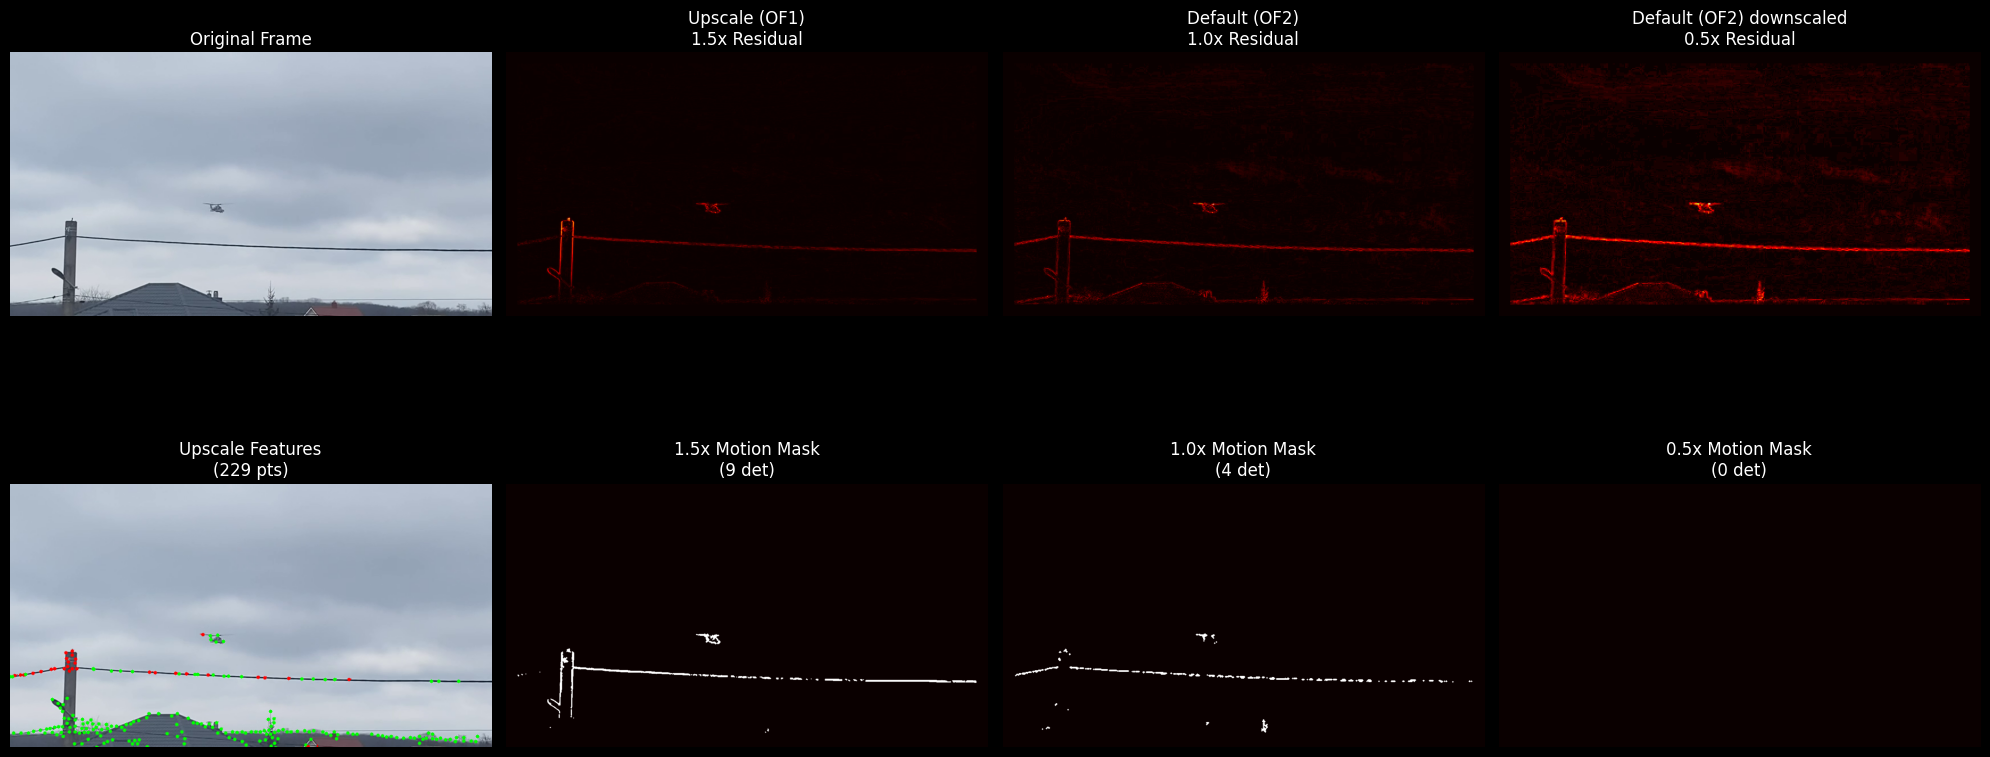

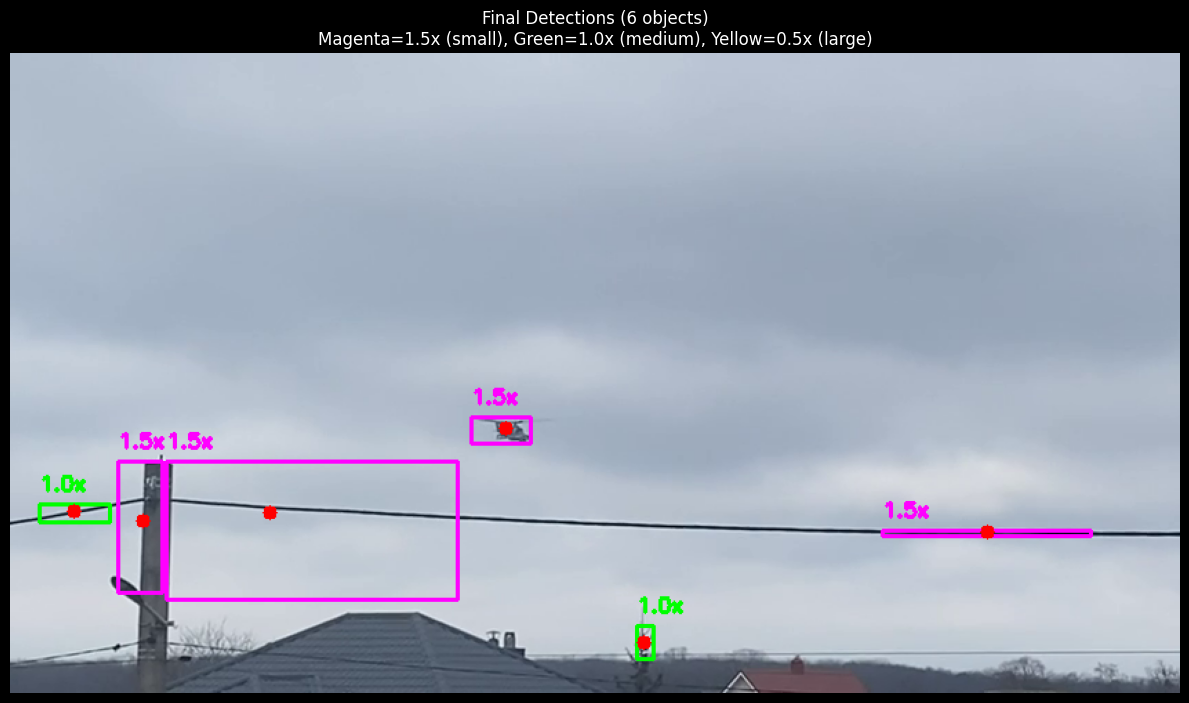

In [9]:
# ============================================
# Analyze Single Frame
# ============================================

def analyze_single_frame(video_path, frame_num=30):
    """
    Detailed analysis of a single frame showing both pipelines.
    """
    cap = cv2.VideoCapture(video_path)
    
    # Read frames up to target
    processor = DualOpticalFlowProcessor()
    
    ret, first_frame = cap.read()
    processor.initialize(first_frame)
    
    for i in range(1, frame_num + 1):
        ret, frame = cap.read()
        if not ret:
            print(f"Cannot read frame {i}")
            return
        
        if i == frame_num:
            detections, scale_info = processor.process_frame(frame)
        else:
            processor.process_frame(frame)
    
    cap.release()
    
    # Visualize
    print(f"\n{'=' * 60}")
    print(f"Frame {frame_num} Analysis - Dual Optical Flow")
    print(f"{'=' * 60}")
    
    print(f"\nTotal detections (after merge): {len(detections)}")
    print(f"\nPer-scale breakdown:")
    for info in scale_info:
        debug = info.get('debug', {})
        print(f"  {info['pipeline']} ({info['scale']:.1f}x):")
        print(f"    Tracked points: {debug.get('tracked_pts', 0)}")
        print(f"    Inliers: {debug.get('inliers', 0)}")
        print(f"    Threshold: {info.get('threshold', 0):.1f}")
        print(f"    Raw detections: {info.get('raw_detections', 0)}")
    
    # Create visualization
    n_scales = len(scale_info)
    fig, axes = plt.subplots(2, n_scales + 1, figsize=(5 * (n_scales + 1), 10))
    
    # Row 1: Original + Residuals
    axes[0, 0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Original Frame')
    axes[0, 0].axis('off')
    
    for i, info in enumerate(scale_info):
        if info['residual'] is not None:
            axes[0, i + 1].imshow(info['residual'], cmap='hot')
        axes[0, i + 1].set_title(f"{info['pipeline']}\n{info['scale']:.1f}x Residual")
        axes[0, i + 1].axis('off')
    
    # Row 2: Motion masks + Final
    # Show tracked features from upscale pipeline
    upscale_info = scale_info[0] if scale_info else None
    if upscale_info and 'old_pts' in upscale_info.get('debug', {}):
        debug = upscale_info['debug']
        inlier_mask_flat = debug.get('inlier_mask')
        if inlier_mask_flat is not None:
            inlier_mask_flat = inlier_mask_flat.ravel()
        features_vis = draw_tracked_features(
            frame, debug['old_pts'], debug['new_pts'],
            inlier_mask_flat,
            scale=upscale_info['scale']
        )
        axes[1, 0].imshow(cv2.cvtColor(features_vis, cv2.COLOR_BGR2RGB))
        axes[1, 0].set_title(f"Upscale Features\n({debug.get('tracked_pts', 0)} pts)")
    axes[1, 0].axis('off')
    
    for i, info in enumerate(scale_info):
        if info['motion_mask'] is not None:
            axes[1, i + 1].imshow(info['motion_mask'], cmap='hot')
        axes[1, i + 1].set_title(f"{info['scale']:.1f}x Motion Mask\n({info.get('raw_detections', 0)} det)")
        axes[1, i + 1].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/analysis_frame_{frame_num}.png", dpi=150)
    plt.show()
    
    # Show final detections
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    output = draw_detections(frame, detections)
    ax.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Final Detections ({len(detections)} objects)\n'
                 'Magenta=1.5x (small), Green=1.0x (medium), Yellow=0.5x (large)')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/detections_frame_{frame_num}.png", dpi=150)
    plt.show()

# Analyze frame 30
analyze_single_frame(VIDEO_PATH, frame_num=30)

## How Dual Optical Flow Works

### Why Two Optical Flows?

Single optical flow has limitations:
- At original resolution, small objects may have few/no trackable features
- Parameters optimized for one scale may not work well for others

### Pipeline 1: Upscale (1.5x) - OF1

**Purpose**: Detect small moving objects

**How it works**:
1. Upscale both frames to 1.5x resolution
2. Detect features with more sensitive parameters (lower quality threshold)
3. Track with smaller window (finer precision)
4. Compute ego-motion (H1) and residual at 1.5x
5. Detect motion at 1.5x scale
6. Scale detections back to original coordinates

**Advantages**:
- Small objects have more pixels → more features detected ON the object
- Better separation of small moving objects from background
- Finer tracking precision

### Pipeline 2: Default (1.0x → 0.5x) - OF2

**Purpose**: Detect medium and large moving objects

**How it works**:
1. Process at original resolution
2. Standard feature detection and tracking
3. Compute ego-motion (H2) and residual
4. Detect motion at 1.0x (medium objects)
5. Downscale residual to 0.5x
6. Detect motion at 0.5x (large objects)
7. Scale 0.5x detections back to original coordinates

**Why share residual for 0.5x**:
- The ego-motion is the same regardless of detection scale
- Only the detection parameters change
- Saves computation (one OF instead of two)

### Parameter Differences

| Parameter | OF1 Upscale (1.5x) | OF2 Default (1.0x) | Why |
|-----------|--------------------|--------------------|-----|
| maxCorners | 500 | 400 | More features at higher res |
| qualityLevel | 0.005 | 0.01 | More sensitive at upscale |
| minDistance | 10 | 15 | Scaled proportionally |
| winSize | (15,15) | (21,21) | Smaller for fine details |
| maxLevel | 4 | 3 | More levels for larger image |

### Detection Merging

Detections from all three scales (1.5x, 1.0x, 0.5x) are merged using NMS:
- Overlapping detections are combined
- Preference given to scales closer to 1.0x (more reliable)
- Final detections tagged with source scale

### Color Coding
- **Magenta**: Detected at 1.5x (small objects via OF1)
- **Green**: Detected at 1.0x (medium objects via OF2)  
- **Yellow**: Detected at 0.5x (large objects via OF2)